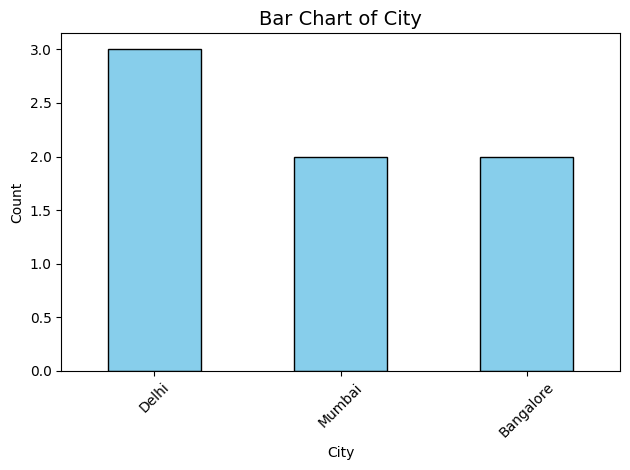

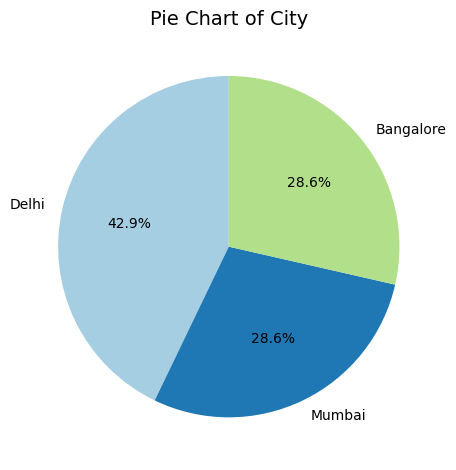

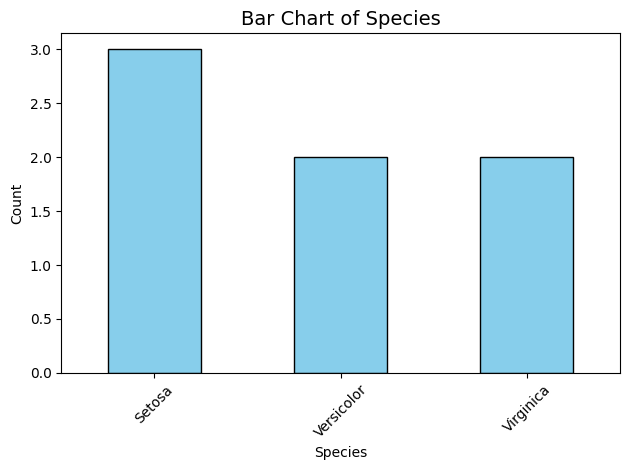

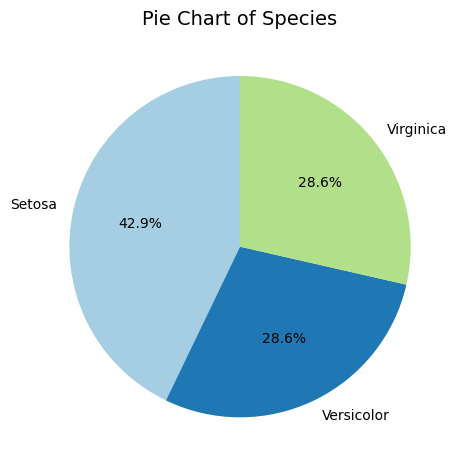

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Example data loading (replace with actual paths)
# df_zomato = pd.read_csv('zomato.csv')
# df_iris = pd.read_csv('iris.csv')

# For demonstration, let's create example nominal columns
df_zomato = pd.DataFrame({
    'City': ['Delhi', 'Mumbai', 'Delhi', 'Bangalore', 'Mumbai', 'Bangalore', 'Delhi'],
    'Online Order': ['Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No']
})

df_iris = pd.DataFrame({
    'Species': ['Setosa', 'Versicolor', 'Virginica', 'Setosa', 'Virginica', 'Versicolor', 'Setosa']
})

# Function to plot bar chart for nominal data
def plot_bar_chart(data, column):
    counts = data[column].value_counts()
    counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f'Bar Chart of {column}', fontsize=14)
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Function to plot pie chart for nominal data
def plot_pie_chart(data, column):
    counts = data[column].value_counts()
    counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title(f'Pie Chart of {column}', fontsize=14)
    plt.ylabel('')  # Hide y-label for cleaner look
    plt.tight_layout()
    plt.show()

# Visualize Zomato City
plot_bar_chart(df_zomato, 'City')
plot_pie_chart(df_zomato, 'City')

# Visualize Iris Species
plot_bar_chart(df_iris, 'Species')
plot_pie_chart(df_iris, 'Species')


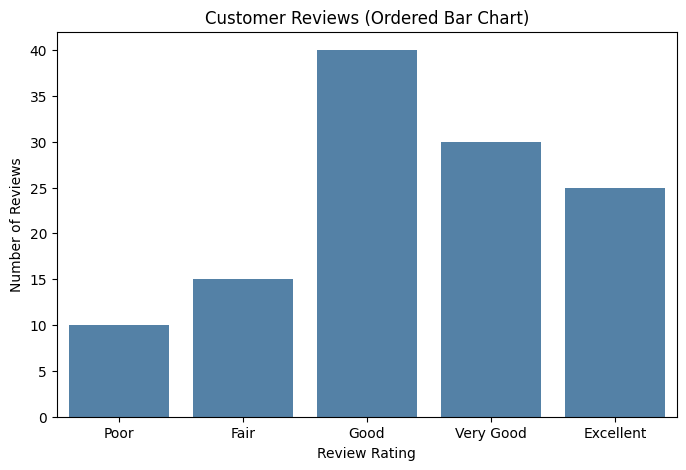

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample ordinal data for customer reviews
data = {
    'Review': ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'],
    'Count': [10, 15, 40, 30, 25]
}

df = pd.DataFrame(data)

# Define the order explicitly to preserve ordinal relationship
order = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']

# Convert 'Review' to a categorical type with order
df['Review'] = pd.Categorical(df['Review'], categories=order, ordered=True)

# Pick one color for all bars (e.g., blue)
bar_color = 'steelblue'

plt.figure(figsize=(8,5))
sns.barplot(x='Review', y='Count', data=df, order=order, color=bar_color)
plt.title('Customer Reviews (Ordered Bar Chart)')
plt.xlabel('Review Rating')
plt.ylabel('Number of Reviews')
plt.show()


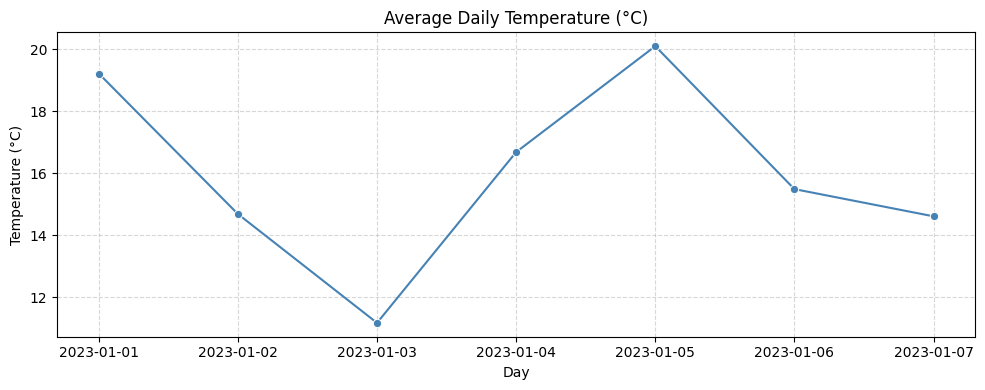

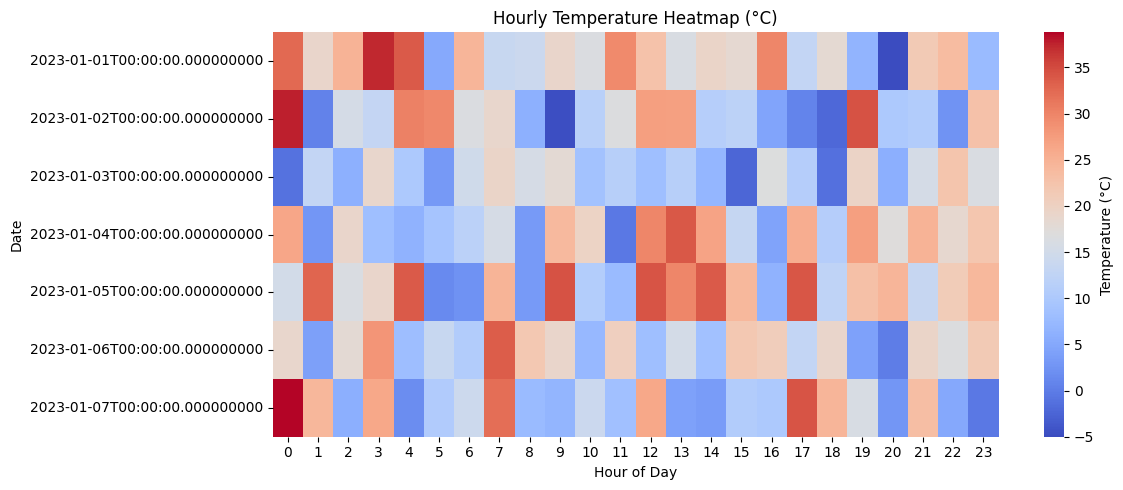

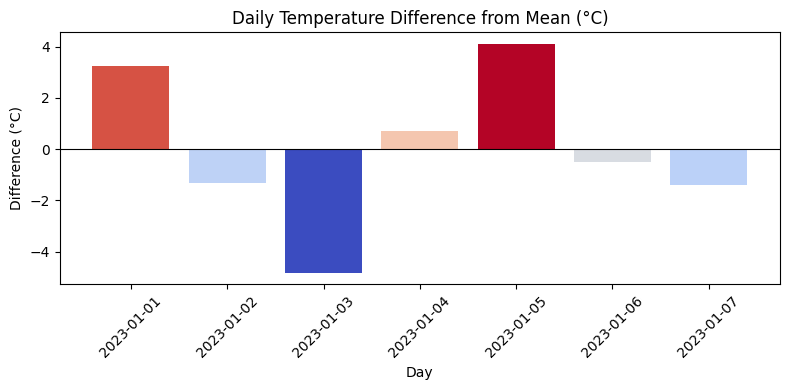

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample interval data: temperatures (°C) over 7 days, hourly
np.random.seed(0)
days = pd.date_range(start='2023-01-01', periods=7)
hours = list(range(24))

# Create DataFrame: rows=days, columns=hours, values=random temps around 15°C ±10°C
temps = pd.DataFrame(
    np.random.normal(loc=15, scale=10, size=(7, 24)),
    index=days,
    columns=hours
).round(1)

# Fix some negative temps to keep realistic range (just for display)
temps[temps < -5] = -5

# 1. Line chart: Average daily temperature trend
plt.figure(figsize=(10,4))
daily_avg = temps.mean(axis=1)
sns.lineplot(x=daily_avg.index, y=daily_avg.values, marker='o', color='steelblue')
plt.title('Average Daily Temperature (°C)')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Heatmap: Hourly temperature by day
plt.figure(figsize=(12,5))
sns.heatmap(temps, cmap='coolwarm', cbar_kws={'label': 'Temperature (°C)'})
plt.title('Hourly Temperature Heatmap (°C)')
plt.xlabel('Hour of Day')
plt.ylabel('Date')
plt.tight_layout()
plt.show()

# 3. Bar chart: Temperature difference from average (daily)
temp_diff = daily_avg - daily_avg.mean()
colors = sns.color_palette("coolwarm", as_cmap=True)
norm = plt.Normalize(temp_diff.min(), temp_diff.max())
bar_colors = plt.cm.coolwarm(norm(temp_diff.values))

plt.figure(figsize=(8,4))
plt.bar(temp_diff.index.strftime('%Y-%m-%d'), temp_diff, color=bar_colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Daily Temperature Difference from Mean (°C)')
plt.xlabel('Day')
plt.ylabel('Difference (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


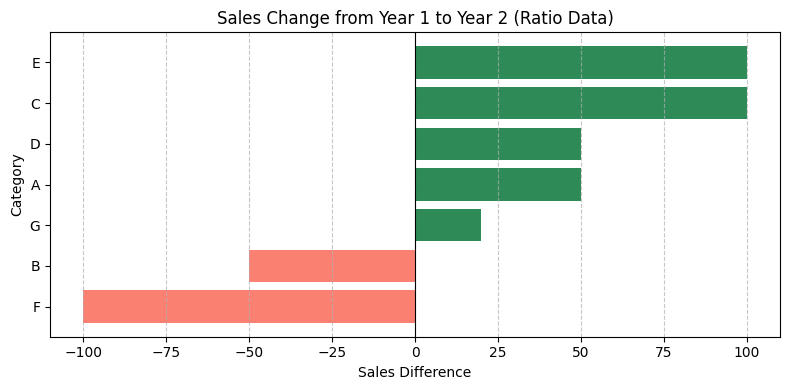

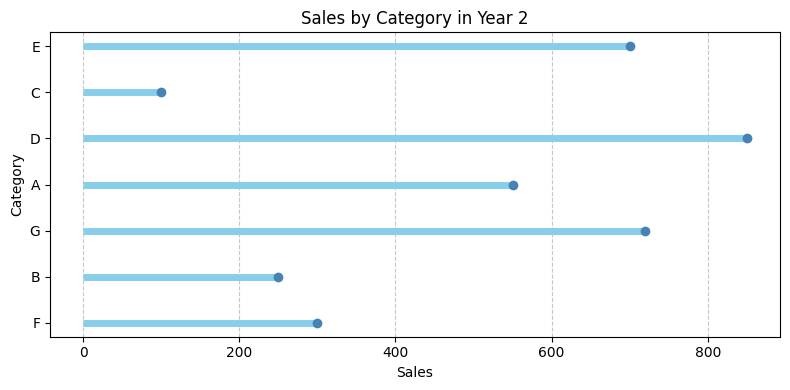

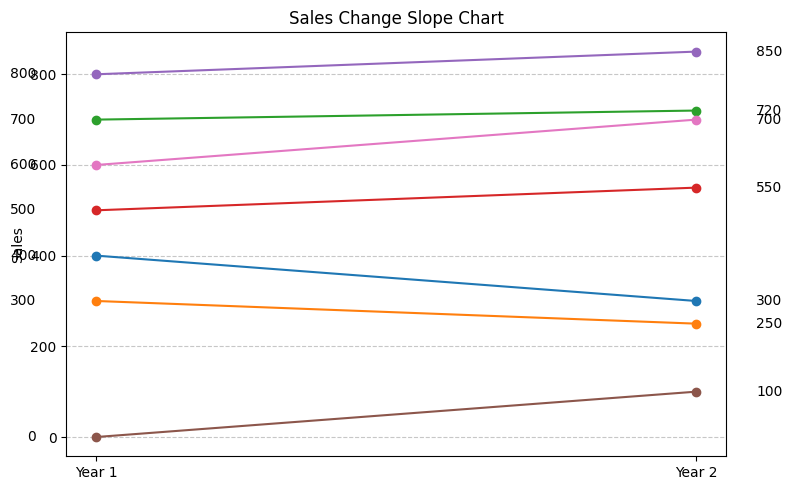

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample ratio data: sales by category for 2 years
data = {
    'Category': ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    'Sales_Year1': [500, 300, 0, 800, 600, 400, 700],
    'Sales_Year2': [550, 250, 100, 850, 700, 300, 720],
}

df = pd.DataFrame(data)

# Calculate difference for diverging bar chart
df['Diff'] = df['Sales_Year2'] - df['Sales_Year1']
df = df.sort_values('Diff')

# Color palette for diverging bars
palette = ['salmon' if x < 0 else 'seagreen' for x in df['Diff']]

# 1. Diverging Bar Chart: Sales change from Year 1 to Year 2
plt.figure(figsize=(8,4))
plt.barh(df['Category'], df['Diff'], color=palette)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Sales Change from Year 1 to Year 2 (Ratio Data)')
plt.xlabel('Sales Difference')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Lollipop Chart: Sales by category in Year 2
plt.figure(figsize=(8,4))
plt.hlines(y=df['Category'], xmin=0, xmax=df['Sales_Year2'], color='skyblue', linewidth=5)
plt.plot(df['Sales_Year2'], df['Category'], "o", color='steelblue')
plt.title('Sales by Category in Year 2')
plt.xlabel('Sales')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Optional: Slope Chart showing sales change from Year 1 to Year 2
plt.figure(figsize=(8,5))
for idx, row in df.iterrows():
    plt.plot([1, 2], [row['Sales_Year1'], row['Sales_Year2']], marker='o')
    plt.text(1 - 0.1, row['Sales_Year1'], f"{row['Sales_Year1']}", ha='right', va='center')
    plt.text(2 + 0.1, row['Sales_Year2'], f"{row['Sales_Year2']}", ha='left', va='center')

plt.xticks([1, 2], ['Year 1', 'Year 2'])
plt.title('Sales Change Slope Chart')
plt.ylabel('Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
